# Lecture 4d — What survives the trip to Australia

**AI-powered Investment and Risk Management · Robo-Advisers and Automated Investment Platforms**

---

## The question

Tax-loss harvesting is the feature American robo-advisers market hardest. Sell a holding that
has fallen, book the capital loss against your tax bill, immediately buy something almost
identical so you never leave the market. The platforms quote it as roughly a percentage point a
year of extra after-tax return — comfortably more than their fee, which makes the whole product
look free.

The logic is clean and the arithmetic is simple. It is also built entirely on the United States
Internal Revenue Code, and almost every step of it changes when you cross the Pacific.

> **How much of the American tax-loss harvesting benefit survives Australian tax law, and what
> does the naive calculation get wrong?**

We will build the engine, run it under both regimes, and price the gap. The naive formula that
appears in nearly every teaching implementation — and in a good number of production ones —
turns out to overstate the Australian benefit by roughly a factor of six. The overstatement
comes from three separate places, and each one is worth understanding on its own.

## The layer

Still the **execution** layer. Notebook 4c established that in a taxable account the tax
consequence of a trade dwarfs its trading cost. This notebook asks whether that consequence can
be turned around and made to work for the client.

---

### How to use this notebook

* Runs end to end in **about 30 seconds**. No internet, no downloads.
* Prose is for a finance-first reader; the tax mechanics sit in collapsible boxes.
* Exercises are tiered **Core** and **Stretch**.

> **This notebook is teaching material, not tax advice.** The rules modelled here are
> simplified, the parameters are illustrative, and Part IVA questions in particular turn on
> facts and purpose rather than arithmetic. Nothing here should be relied on for a real
> client or a real return.


## 0 · Setup

The portfolio is a **directly indexed** equity sleeve: forty individual stocks rather than a
single ETF. This matters enormously and is the reason direct indexing exists as a product.

Harvesting needs losses, and losses come from dispersion. An index fund can only be harvested
when the whole index is down. A basket of forty stocks contains losers even in a year when the
index rises — that idiosyncratic dispersion is the raw material of the entire strategy. Running
this notebook on two ETFs instead of forty stocks cuts the harvest yield by roughly an order of
magnitude, which is precisely why the platforms quoting the biggest numbers are all
direct-indexing platforms.

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

SEED   = 20260811
YEARS, PATHS, MONTHS, N_STOCKS = 20, 30, 240, 40
W0, CONTRIB_PA = 100_000.0, 6_000.0

MKT_MU, MKT_SD, IDIO_SD = 0.080, 0.16, 0.26     # market drift, market vol, idiosyncratic vol
OTHER_GAINS = 0.02        # capital gains realised elsewhere each year, as a share of wealth
DISCOUNT    = 0.045       # rate used to present-value the tax timing

# --- United States -----------------------------------------------------------
US_SHORT, US_LONG, US_INCOME_CAP = 0.37, 0.20, 3_000.0

# --- Australia ---------------------------------------------------------------
AU_RATE, AU_CGT_DISCOUNT = 0.47, 0.50           # top marginal rate; 50% discount after 12 months
AU_EFFECTIVE = AU_RATE * (1 - AU_CGT_DISCOUNT)  # effective rate on a discounted gain

SUBSTITUTE = (np.arange(N_STOCKS) + N_STOCKS // 2) % N_STOCKS   # factor-matched replacement

NAVY, BAND, RED, GREY, GOLD = '#123F69', '#E2EBF4', '#C0392B', '#7F8C8D', '#B7950B'
TEMPLATE = dict(layout=go.Layout(
    font=dict(family='Georgia, serif', size=13), plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='#EEEEEE', zeroline=False),
    yaxis=dict(showgrid=True, gridcolor='#EEEEEE', zeroline=False),
    margin=dict(l=60, r=30, t=60, b=50)))

print(f"Australian effective CGT rate on a discounted gain: {AU_EFFECTIVE:.1%}")
print(f"US long-term capital gains rate:                    {US_LONG:.1%}")
print(f"US short-term / ordinary income rate:               {US_SHORT:.1%}")

Australian effective CGT rate on a discounted gain: 23.5%
US long-term capital gains rate:                    20.0%
US short-term / ordinary income rate:               37.0%


### The three differences that matter

<details>
<summary><b>Australian versus American capital gains treatment (click to open)</b></summary>

**1 · There is no wash-sale rule, and that is worse, not better.**
The United States has a bright-line test: repurchase a substantially identical security within
30 days either side of the sale and the loss is disallowed. It is restrictive, but it is
*certain* — an engine can be coded against it.

Australia has no such provision. Instead the general anti-avoidance rule, **Part IVA** of the
*Income Tax Assessment Act 1936*, applies. The ATO's ruling **TR 2008/1** sets out how Part IVA
applies to wash-sale arrangements, and **TA 2008/7** is a taxpayer alert covering disposal and
reacquisition by the taxpayer, a spouse, a family trust or an SMSF. The test is **dominant
purpose**, and whether the economic exposure substantively changed.

An automated harvesting engine is a documented, repeated, systematic arrangement whose stated
commercial rationale is tax. That is close to the least favourable fact pattern imaginable under
a dominant-purpose test. There is no bright line to code against and no safe harbour to sit
inside.

**2 · Losses are applied to gross gains, before the 50% discount.**
This is the single most consequential difference and the one most often missed. The Australian
order of operations is:

1. Work out capital gains and capital losses for the year.
2. Apply capital losses against **gross** capital gains.
3. Apply the 50% discount to whatever discountable gain remains.

So a $1 capital loss removes $1 of *gross* gain. Had that gain survived, only $0.50 would have
been taxable. The loss therefore shelters $0.50 of taxable income, saving $0.50 × 47% = **23.5
cents**, not 47 cents. Any engine computing `loss × marginal_rate` doubles the benefit.

Because losses must be applied before the discount, the optimal ordering is to apply them
against **non-discounted** gains first — assets held under twelve months — and only then against
discounted ones. Our engine does this.

**3 · There is no ordinary-income offset.**
An American investor can apply up to US$3,000 of net capital losses against ordinary income each
year, at their marginal rate. In Australia capital losses may be applied against capital gains
only. Surplus losses carry forward indefinitely with no expiry — which is generous — but they
earn nothing while they wait, and a client with no capital gains gets no benefit at all in the
year the loss is realised.

**Also relevant, though not modelled here:** the 45-day holding rule for franking credits, the
different arithmetic inside superannuation where the rate is 15% and the discount is one third,
and CGT event timing on contract date rather than settlement.
</details>

---

## 1 · The engine

Below is a lot-level harvesting engine. It tracks every parcel separately — units, cost base,
purchase month, stock — because tax is assessed parcel by parcel and no aggregate shortcut
survives contact with a real ledger.

One design detail is worth flagging because it is how real engines behave and it is not
obvious. **Monthly contributions are directed only to stocks currently trading above their
average cost.** This is deliberate: buying a stock you might want to harvest would start a
wash-sale clock on it. Routing new money to winners keeps the losers clean and harvestable.

In [2]:
def price_paths(rng):
    """One market factor plus idiosyncratic noise, forty stocks, monthly."""
    mkt  = (MKT_MU - 0.5 * MKT_SD ** 2) / 12 + MKT_SD / np.sqrt(12) * rng.normal(size=(MONTHS, 1))
    idio = (-0.5 * IDIO_SD ** 2) / 12 + IDIO_SD / np.sqrt(12) * rng.normal(size=(MONTHS, N_STOCKS))
    return 100 * np.exp(np.cumsum(mkt + idio, axis=0))


def run_ledger(prices, threshold, wash_lockout, harvest=True):
    """Simulate one client. Returns realised short/long gains by year, gross losses
    harvested by year, terminal value, terminal cost base, and blocked harvest count."""
    units = np.full(N_STOCKS, W0 / N_STOCKS / 100.0)
    basis = np.full(N_STOCKS, 100.0)
    bought = np.zeros(N_STOCKS, int)
    stock = np.arange(N_STOCKS)
    last_purchase = np.full(N_STOCKS, -99)

    short = np.zeros(YEARS); long_ = np.zeros(YEARS)
    gross_losses = np.zeros(YEARS); blocked = 0

    for m in range(MONTHS):
        px = prices[m]

        # ---- contribute, directing new money to stocks above their average cost ----
        held = np.bincount(stock, weights=units, minlength=N_STOCKS)
        cost = np.bincount(stock, weights=units * basis, minlength=N_STOCKS)
        avg_cost = np.divide(cost, held, out=np.full(N_STOCKS, np.inf), where=held > 1e-12)
        winners = np.flatnonzero(px >= avg_cost)
        if winners.size == 0:
            winners = np.arange(N_STOCKS)
        units  = np.concatenate([units, CONTRIB_PA / 12 / winners.size / px[winners]])
        basis  = np.concatenate([basis, px[winners]])
        bought = np.concatenate([bought, np.full(winners.size, m)])
        stock  = np.concatenate([stock, winners])
        last_purchase[winners] = m

        if not harvest:
            continue

        # ---- harvest ----
        current = px[stock]
        eligible = ((current - basis) / basis < -threshold) & (units * current > 250)
        allowed  = eligible & ((m - last_purchase[stock]) >= wash_lockout)
        blocked += int((eligible & ~allowed).sum())

        if allowed.any():
            gain = units[allowed] * (current[allowed] - basis[allowed])
            y = m // 12
            is_short = (m - bought[allowed]) < 12
            short[y] += gain[is_short].sum()
            long_[y] += gain[~is_short].sum()
            gross_losses[y] += np.abs(gain).sum()

            sub = SUBSTITUTE[stock[allowed]]                 # buy a factor-matched replacement
            proceeds = units[allowed] * current[allowed]
            keep = ~allowed
            units  = np.concatenate([units[keep],  proceeds / px[sub]])
            basis  = np.concatenate([basis[keep],  px[sub]])
            bought = np.concatenate([bought[keep], np.full(allowed.sum(), m)])
            stock  = np.concatenate([stock[keep],  sub])
            last_purchase[np.unique(sub)] = m

    px = prices[-1]
    return short, long_, gross_losses, float((units * px[stock]).sum()), float((units * basis).sum()), blocked

In [3]:
def tax_saved_us(short, long_, other_gains):
    """US: net short against short, long against long, cross-offset, then up to
    US$3,000 against ordinary income. Surplus carries forward."""
    saved = np.zeros(YEARS); carry = 0.0
    for y in range(YEARS):
        s, l = short[y], long_[y] + other_gains[y]
        loss = -(min(s, 0) + min(l, 0)) + carry
        use_s = min(loss, max(s, 0)); loss -= use_s
        use_l = min(loss, max(l, 0)); loss -= use_l
        use_i = min(loss, US_INCOME_CAP); loss -= use_i
        saved[y] = use_s * US_SHORT + use_l * US_LONG + use_i * US_SHORT
        carry = loss
    return saved, carry


def tax_saved_au(short, long_, other_gains):
    """Australia: losses applied to GROSS gains before the 50% discount, undiscounted
    gains sheltered first, surplus carried forward indefinitely, no income offset."""
    saved = np.zeros(YEARS); carry = 0.0
    for y in range(YEARS):
        loss = -(min(short[y], 0) + min(long_[y], 0)) + carry
        gain_undiscounted = max(short[y], 0)                       # held under 12 months
        gain_discounted   = max(long_[y], 0) + other_gains[y]      # held over 12 months
        use_u = min(loss, gain_undiscounted); loss -= use_u
        use_d = min(loss, gain_discounted);   loss -= use_d
        saved[y] = use_u * AU_RATE + use_d * AU_EFFECTIVE
        carry = loss
    return saved, carry


def present_value(stream):
    return float(sum(stream[y] / (1 + DISCOUNT) ** (y + 1) for y in range(YEARS)))

rng = np.random.default_rng(SEED)
PATHSET = [price_paths(rng) for _ in range(PATHS)]
OTHER = np.array([OTHER_GAINS * W0 * 1.06 ** y for y in range(YEARS)])
ZERO = np.zeros(YEARS)
BASE_US, _ = tax_saved_us(ZERO, ZERO, OTHER)      # tax paid with no harvesting at all
BASE_AU, BASE_CARRY = tax_saved_au(ZERO, ZERO, OTHER)
print(f"simulated {PATHS} clients, {N_STOCKS} stocks, {YEARS} years")
print(f"starting wealth ${W0:,.0f}, contributions ${CONTRIB_PA:,.0f} p.a.")
print(f"capital gains realised elsewhere: {OTHER_GAINS:.0%} of wealth p.a.")

simulated 30 clients, 40 stocks, 20 years
starting wealth $100,000, contributions $6,000 p.a.
capital gains realised elsewhere: 2% of wealth p.a.


---

## 2 · Four ways to value the same losses

We now run the engine once and value the harvested losses four different ways. The four are not
alternative opinions; they are a naive calculation and three successive corrections to it.

1. **Naive.** `loss × marginal rate`, undiscounted. This is the formula in almost every teaching
   implementation. It treats the benefit as immediate, permanent, and taxed at the full marginal
   rate.
2. **US rules.** The short/long split, the ordinary-income offset, and carry-forward.
3. **Australian rules.** Losses applied to gross gains before the 50% discount, undiscounted
   gains sheltered first, no income offset, indefinite carry-forward.
4. **Australian rules, net of the deferral reversal.** Harvesting resets the cost base downward,
   so every dollar of loss claimed today becomes a dollar of extra gain at liquidation. The
   benefit is a *timing* benefit, not a saving.

<details>
<summary><b>Why the reversal is exactly the harvested loss (click to open)</b></summary>

Sell a parcel with cost base $b$ at price $p < b$ and immediately buy a substitute at $p$. You
realise a loss of $b - p$ and your cost base falls from $b$ to $p$.

At liquidation the substitute is worth $P$. Your gain is $P - p$ rather than $P - b$: larger by
exactly $b - p$, the loss you harvested. Losses that never found a gain to offset survive as a
carried-forward balance and cancel against that larger gain at liquidation, so they are exactly
neutral.

The net benefit is therefore

$$\underbrace{\sum_t \frac{L_t \cdot \tau}{(1+r)^{t}}}_{\text{claimed as you go}}
\; - \; \underbrace{\frac{L \cdot \tau}{(1+r)^{T}}}_{\text{repaid at liquidation}}$$

where $L_t$ is the loss used in year $t$, $L$ the total used, and $\tau$ the effective rate.
This is positive because the claims come earlier than the repayment, but it is far smaller than
$L\tau$. Harvesting is an interest-free loan from the tax office, not a gift — and its value is
the interest on that loan, not its face value.

It follows that the benefit rises with the discount rate and with the holding period before
liquidation, and falls to nothing if the client liquidates next year. The reversal is avoided
altogether only if the assets are never sold — bequeathed, or gifted to a charity — and
Australia has no equivalent of the American step-up in basis at death, so even that escape is
narrower here.
</details>

In [4]:
def evaluate(threshold, wash_lockout, label):
    acc = {k: [] for k in ['naive', 'us', 'au', 'net', 'avg_value', 'blocked',
                           'used', 'carry', 'tracking']}
    annual_au = np.zeros(YEARS)
    for prices in PATHSET:
        short, long_, gl, val, bas, blk = run_ledger(prices, threshold, wash_lockout)
        _, _, _, val0, bas0, _ = run_ledger(prices, 0, 0, harvest=False)

        us, _        = tax_saved_us(short, long_, OTHER)
        au, carry    = tax_saved_au(short, long_, OTHER)
        us, au       = us - BASE_US, au - BASE_AU
        used         = gl.sum() - carry                    # losses that found a gain to offset
        reversal     = used * AU_EFFECTIVE / (1 + DISCOUNT) ** YEARS

        acc['naive'].append(present_value(gl * AU_RATE))
        acc['us'].append(present_value(us))
        acc['au'].append(present_value(au))
        acc['net'].append(present_value(au) - reversal)
        acc['avg_value'].append((W0 + val) / 2)
        acc['blocked'].append(blk); acc['used'].append(used); acc['carry'].append(carry)
        acc['tracking'].append(val - val0)
        annual_au += au / len(PATHSET)

    d = {k: float(np.mean(v)) for k, v in acc.items()}
    d['bp'] = lambda x: x / d['avg_value'] * 1e4 / YEARS
    d['annual_au'] = annual_au
    d['label'] = label
    d['tracking_sd'] = float(np.std(acc['tracking']))
    return d


main = evaluate(threshold=0.05, wash_lockout=1, label='5% threshold, 30-day wash-sale rule')
bp = main['bp']

ladder = pd.DataFrame([
    {'Valuation': '1. Naive: loss x 47%, no reversal',        'PV ($)': f"{main['naive']:,.0f}", 'bp p.a.': f"{bp(main['naive']):.1f}"},
    {'Valuation': '2. US rules: short/long split + income offset', 'PV ($)': f"{main['us']:,.0f}",    'bp p.a.': f"{bp(main['us']):.1f}"},
    {'Valuation': '3. AU rules: loss applied before 50% discount', 'PV ($)': f"{main['au']:,.0f}",    'bp p.a.': f"{bp(main['au']):.1f}"},
    {'Valuation': '4. AU rules, net of deferral reversal',    'PV ($)': f"{main['net']:,.0f}", 'bp p.a.': f"{bp(main['net']):.1f}"}])
print(f"{main['label']}   |   mean terminal portfolio ${main['avg_value']*2 - W0:,.0f}\n")
print(ladder.to_string(index=False))
print(f"\nThe naive figure overstates the truth by {main['naive'] / main['net']:.1f}x.")
print(f"Total losses harvested that found a gain to offset: ${main['used']:,.0f}")
print(f"Losses still carried forward after {YEARS} years:    ${main['carry']:,.0f}")

5% threshold, 30-day wash-sale rule   |   mean terminal portfolio $851,185

                                    Valuation PV ($) bp p.a.
            1. Naive: loss x 47%, no reversal 16,166    17.0
2. US rules: short/long split + income offset  7,673     8.1
3. AU rules: loss applied before 50% discount  6,671     7.0
        4. AU rules, net of deferral reversal  2,640     2.8

The naive figure overstates the truth by 6.1x.
Total losses harvested that found a gain to offset: $41,371
Losses still carried forward after 20 years:    $0


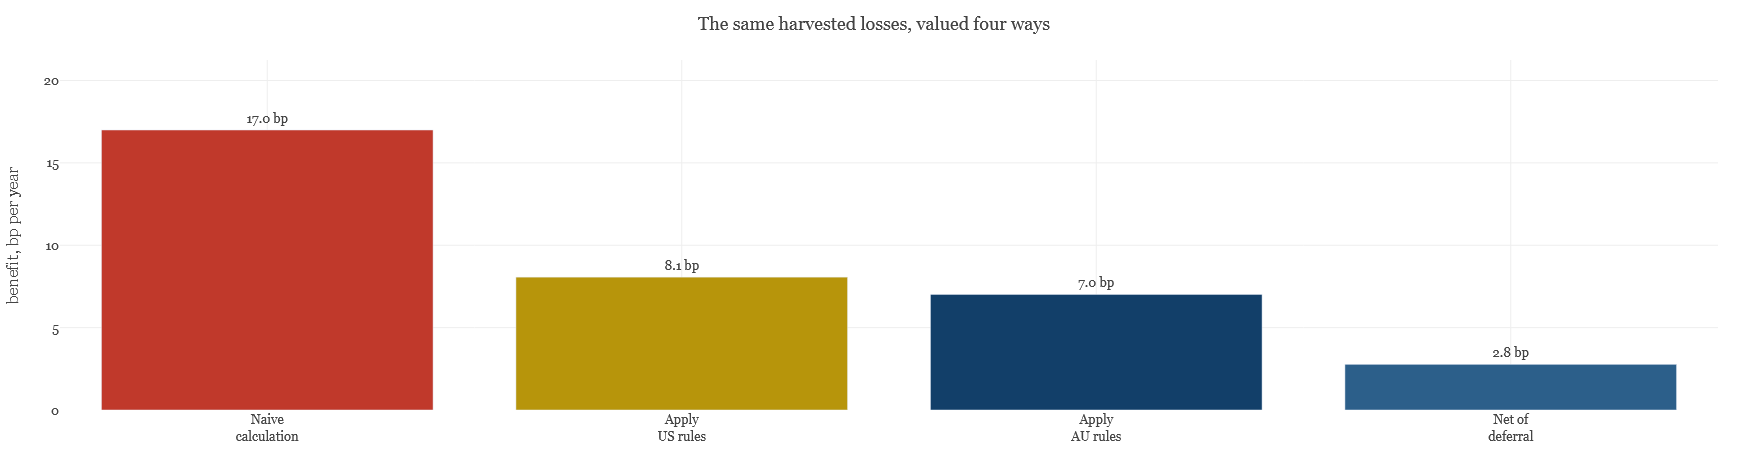

Step 1 -> 2  (US rules):        17.0 -> 8.1 bp   (53% of the naive figure removed)
Step 2 -> 3  (AU rules):        8.1 -> 7.0 bp
Step 3 -> 4  (deferral):        7.0 -> 2.8 bp   (60% of the gross benefit removed)


In [5]:
steps = ['Naive\ncalculation', 'Apply\nUS rules', 'Apply\nAU rules', 'Net of\ndeferral']
vals  = [bp(main['naive']), bp(main['us']), bp(main['au']), bp(main['net'])]

fig = go.Figure(go.Bar(x=[s.replace('\n', '<br>') for s in steps], y=vals,
                       marker_color=[RED, GOLD, NAVY, '#2C5F8A'],
                       text=[f'{v:.1f} bp' for v in vals], textposition='outside',
                       hovertemplate='%{x}<br>%{y:.1f} bp p.a.<extra></extra>'))
fig.add_hline(y=25, line=dict(color=GREY, width=2, dash='dash'),
              annotation_text='a 25 bp advice fee', annotation_position='top right')
fig.update_layout(template=TEMPLATE, height=460, showlegend=False,
                  title_text='The same harvested losses, valued four ways',
                  yaxis_title='benefit, bp per year', yaxis_range=[0, max(vals) * 1.25])
fig.show()

print(f"Step 1 -> 2  (US rules):        {bp(main['naive']):.1f} -> {bp(main['us']):.1f} bp   "
      f"({1 - main['us']/main['naive']:.0%} of the naive figure removed)")
print(f"Step 2 -> 3  (AU rules):        {bp(main['us']):.1f} -> {bp(main['au']):.1f} bp")
print(f"Step 3 -> 4  (deferral):        {bp(main['au']):.1f} -> {bp(main['net']):.1f} bp   "
      f"({1 - main['net']/main['au']:.0%} of the gross benefit removed)")

Two observations that cut against the intuition most students bring to this.

**Australia is not obviously worse than the United States per dollar of loss.** The effective
Australian rate on a discounted gain is 23.5%, which is *above* the American long-term rate of
20%. What Australia removes is the ordinary-income offset and, more importantly, the ability to
value a loss at the full marginal rate. The two regimes land closer together than the folklore
suggests.

**The deferral is where most of the benefit goes, and it applies in both countries.** Roughly
sixty per cent of the gross benefit is repaid at liquidation. This has nothing to do with
jurisdiction — it is the arithmetic of a cost-base reset — and it is missing from the naive
calculation entirely. An engine ported unchanged from a US codebase would still be wrong about
this in New York.

---

## 3 · The benefit decays

A second property the naive calculation misses: harvesting is not an annuity. The opportunity
set shrinks as the portfolio ages, because a portfolio that has grown is a portfolio with fewer
parcels below their cost base.

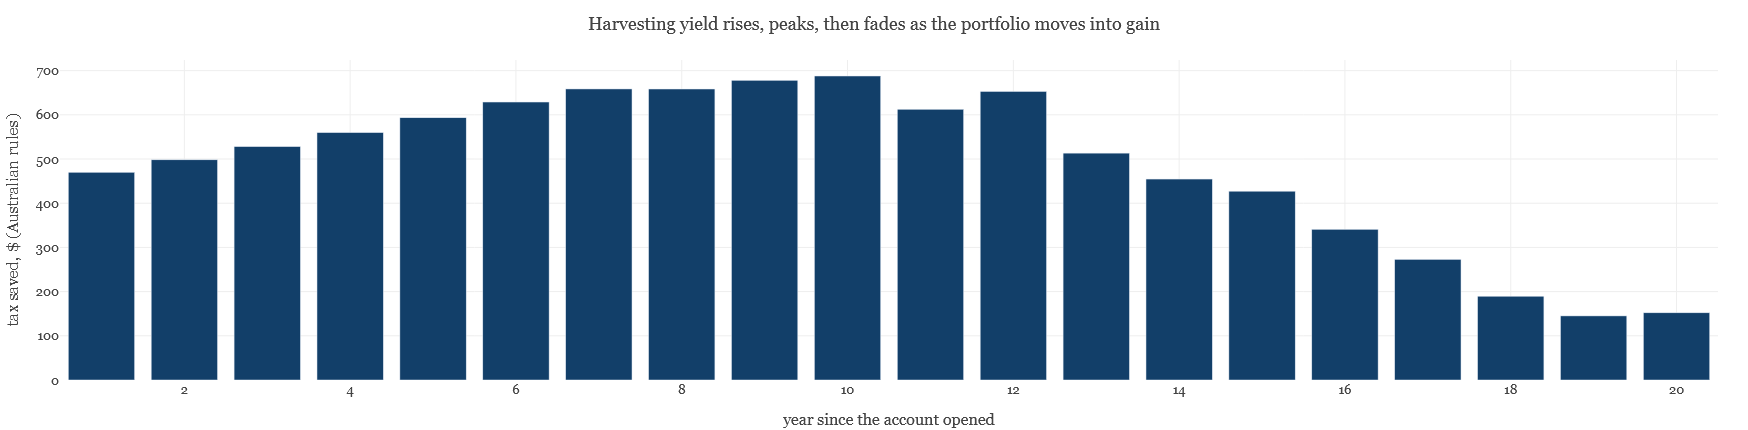

Year 1: $470   peak in year 10: $688   year 20: $152
The final year yields 22% of the peak year.
First half of the period delivers 61% of the total benefit.


In [6]:
fig = go.Figure()
fig.add_trace(go.Bar(x=list(range(1, YEARS + 1)), y=main['annual_au'], marker_color=NAVY,
                     name='tax saved that year',
                     hovertemplate='year %{x}<br>$%{y:,.0f}<extra></extra>'))
fig.update_layout(template=TEMPLATE, height=430, showlegend=False,
                  title_text='Harvesting yield rises, peaks, then fades as the portfolio moves into gain',
                  xaxis_title='year since the account opened', yaxis_title='tax saved, $ (Australian rules)',
                  xaxis=dict(tickmode='linear', dtick=2))
fig.show()

a = main['annual_au']
peak = int(np.argmax(a)) + 1
print(f"Year 1: ${a[0]:,.0f}   peak in year {peak}: ${a.max():,.0f}   year {YEARS}: ${a[-1]:,.0f}")
print(f"The final year yields {a[-1]/a.max():.0%} of the peak year.")
print(f"First half of the period delivers {a[:YEARS//2].sum()/a.sum():.0%} of the total benefit.")

The shape is characteristic. Early on the portfolio is small, so even a good harvest year
produces modest dollars. In the middle years the portfolio is large and still contains plenty of
parcels below cost. By the end almost everything is deep in gain and there is nothing left to
harvest — the strategy has consumed its own raw material.

Any platform quoting a single annual figure for harvesting benefit is quoting an average over a
curve that looks like this. For a client fifteen years in, the marketing number bears very
little relation to what they will actually receive.

---

## 4 · Does the wash-sale rule matter?

The American wash-sale rule is the constraint the literature spends the most effort on, and it
is the one our engine handles most easily.

In [7]:
variants = {
    'No wash-sale rule':          evaluate(0.05, 0,  'no wash-sale rule'),
    '30-day wash-sale rule':      main,
    '2% loss threshold':          evaluate(0.02, 1,  '2% threshold'),
    '10% loss threshold':         evaluate(0.10, 1,  '10% threshold')}

print(pd.DataFrame([{
    'Variant': k,
    'AU gross (bp)': round(v['bp'](v['au']), 1),
    'AU net (bp)':   round(v['bp'](v['net']), 1),
    'US (bp)':       round(v['bp'](v['us']), 1),
    'Harvests blocked': int(v['blocked'])} for k, v in variants.items()]).to_string(index=False))

w_off, w_on = variants['No wash-sale rule'], variants['30-day wash-sale rule']
print(f"\nImposing the wash-sale rule costs {1 - w_on['au']/w_off['au']:.1%} of the gross benefit,")
print(f"blocking {w_on['blocked']:.0f} harvest attempts per client over {YEARS} years.")
print(f"\nMoving the loss threshold from 2% to 10% changes the net benefit from "
      f"{variants['2% loss threshold']['bp'](variants['2% loss threshold']['net']):.1f} to "
      f"{variants['10% loss threshold']['bp'](variants['10% loss threshold']['net']):.1f} bp.")

              Variant  AU gross (bp)  AU net (bp)  US (bp)  Harvests blocked
    No wash-sale rule            7.2          2.8      8.4                 0
30-day wash-sale rule            7.0          2.8      8.1                63
    2% loss threshold            7.2          2.8      8.6                93
   10% loss threshold            7.0          2.8      7.6                44

Imposing the wash-sale rule costs 1.9% of the gross benefit,
blocking 64 harvest attempts per client over 20 years.

Moving the loss threshold from 2% to 10% changes the net benefit from 2.8 to 2.8 bp.


Both levers turn out to be nearly inert, and for the same reason.

**The wash-sale rule barely binds** because the engine routes around it. Contributions go to
winners, replacements go to a different stock, and the rule only ever catches the residual
collisions. This is exactly why the American literature finds the constrained benefit only
modestly below the unconstrained one rather than close to zero.

**The loss threshold barely matters** because the harvest is dominated by deep losses. A stock
down 30% contributes far more than the marginal parcel sitting just either side of a 2% or 10%
trigger. Tuning the threshold is the parameter engineers most enjoy tuning and one of the least
consequential decisions in the system.

What *does* move the answer is the client's supply of capital gains to offset — the one input
the platform does not control and usually cannot see.

In [8]:
sens = []
for og in [0.0, 0.01, 0.02, 0.04, 0.08]:
    o = np.array([og * W0 * 1.06 ** y for y in range(YEARS)])
    b_us, _ = tax_saved_us(np.zeros(YEARS), np.zeros(YEARS), o)
    b_au, _ = tax_saved_au(np.zeros(YEARS), np.zeros(YEARS), o)
    net, gross, unused = [], [], []
    for prices in PATHSET[:15]:
        short, long_, gl, val, bas, _ = run_ledger(prices, 0.05, 1)
        au, carry = tax_saved_au(short, long_, o)
        au = au - b_au
        used = gl.sum() - carry
        gross.append(present_value(au))
        net.append(present_value(au) - used * AU_EFFECTIVE / (1 + DISCOUNT) ** YEARS)
        unused.append(carry / max(gl.sum(), 1))
    sens.append({'External gains, % of wealth p.a.': f"{og:.0%}",
                 'AU gross (bp)': round(np.mean(gross) / main['avg_value'] * 1e4 / YEARS, 1),
                 'AU net (bp)':   round(np.mean(net) / main['avg_value'] * 1e4 / YEARS, 1),
                 'Losses left unused': f"{np.mean(unused):.0%}"})
print("Sensitivity to the client's supply of capital gains elsewhere:\n")
print(pd.DataFrame(sens).to_string(index=False))

Sensitivity to the client's supply of capital gains elsewhere:

External gains, % of wealth p.a.  AU gross (bp)  AU net (bp) Losses left unused
                              0%            0.0          0.0               100%
                              1%            4.8          1.6                 8%
                              2%            6.2          2.6                 0%
                              4%            6.9          3.3                 0%
                              8%            7.3          3.6                 0%


A client with no capital gains anywhere gets nothing in the year the loss is realised. The
loss is real, it is carried forward indefinitely, and it earns nothing while it waits. In the
United States that client would at least receive the ordinary-income offset each year.

This is a serious problem for the Australian product, because it means the value of the feature
depends on something the platform cannot observe: whether the client has an investment property,
a business sale, or a share portfolio elsewhere throwing off gains. A platform quoting a single
harvesting benefit to all clients is quoting a number that is materially wrong for most of them.

---

## 5 · The cost that is not in any of these numbers

Every figure above assumes the replacement security performs identically to the one sold. It
does not. The substitute is a different company with different fortunes, and the tracking
difference accumulates.

In [9]:
se = main['tracking_sd'] / np.sqrt(PATHS)
print("Difference in terminal wealth, harvested vs not harvested:")
print(f"  mean                        ${main['tracking']:>12,.0f}")
print(f"  standard deviation          ${main['tracking_sd']:>12,.0f}")
print(f"  standard error of the mean  ${se:>12,.0f}   (t = {main['tracking']/se:.1f})")
print(f"  dispersion as a share of the terminal portfolio: "
      f"{main['tracking_sd']/(main['avg_value']*2 - W0):.0%}")
print(f"\nFor comparison, the entire net tax benefit has a present value of "
      f"${main['net']:,.0f}.")

Difference in terminal wealth, harvested vs not harvested:
  mean                        $      36,397
  standard deviation          $     142,455
  standard error of the mean  $      26,009   (t = 1.4)
  dispersion as a share of the terminal portfolio: 17%

For comparison, the entire net tax benefit has a present value of $2,640.


The sample mean is positive but sits well inside one and a half standard errors of zero, which
is what theory predicts — swapping one stock for a similar one should not be expected to help or
hurt. Note that with only 30 simulated clients we could not detect a real effect of this size
either way; the mean is not the interesting number here.

The dispersion is. A standard deviation of roughly 17% of terminal wealth, in exchange for a
benefit with a present value of a few thousand dollars, is a poor exchange rate for risk.

That is the honest summary of the whole strategy in Australia. The client is taking on a
material, unrewarded tracking risk in exchange for a timing benefit worth a few basis points a
year, whose realisation depends on capital gains the platform cannot see, and whose legal
foundation is a dominant-purpose test rather than a bright-line rule.

**Part IVA, in one paragraph.** The question is not whether each individual trade is lawful. It
is whether the *arrangement*, viewed as a whole, was entered into for the dominant purpose of
obtaining a tax benefit. An automated engine is documented, systematic, repeated, applied
identically to every client, and marketed on its tax benefit. Every one of those features is
evidence of purpose. The defence has to be that the arrangement has a substantial non-tax
purpose and that economic exposure genuinely changed — which is precisely what the tracking
dispersion above demonstrates, and precisely what a tightly correlated substitute is designed to
minimise. The engineering objective and the legal defence point in opposite directions.

---

## 6 · What this means for design

**Do not port the engine.** Three separate provisions differ, and each one moves the answer by a
large multiple. An engine that computes `loss × marginal_rate` and stops is wrong by roughly a
factor of six in Australia, and it is wrong in the direction that flatters the product.

**Value it as deferral, not saving.** The cost-base reset repays most of the benefit at
liquidation. What remains is the time value of an interest-free loan, which is worth having and
is not worth a percentage point a year.

**The feature is worth less than the fee.** On these assumptions the net benefit is a few basis
points against a 25 bp fee. It cannot make the product free, and marketing it as though it could
is the kind of claim that draws enforcement attention — the SEC's action against Betterment
concerned misstatements about exactly this feature.

**Direct indexing is the precondition, not an enhancement.** Harvesting needs dispersion. An
ETF-based portfolio has almost none. The platforms quoting the largest numbers are all
direct-indexing platforms, and comparing their figures to an ETF-based product is comparing
different strategies.

**What this notebook does not show.** Returns are Gaussian and independent; real markets cluster
their losses, which would raise the early-year harvest. We model one equity sleeve, one marginal
rate, and no franking credits, no superannuation interaction, and no state of the world in which
the client's marginal rate changes — which is one of the few genuine sources of permanent rather
than timing benefit. And we do not model the CGT small business concessions, the main residence
interaction, or trust distributions.

---

## Exercises

### Core

**C1 · The doubling.** Modify `tax_saved_au` to compute `loss × AU_RATE` for all gains, ignoring
the discount ordering. Report the inflated benefit. Then write the two-sentence explanation you
would give a product manager for why the number in the marketing deck must come down.

**C2 · When does it pay?** Find the combination of external capital gains and holding period at
which the net Australian benefit exceeds 10 bp a year. What fraction of a realistic retail client
base would meet it?

**C3 · The superannuation case.** Change `AU_RATE` to 0.15 and `AU_CGT_DISCOUNT` to 1/3 to model
harvesting inside super. Does the feature become more or less attractive, and why is the answer
not obvious?

**C4 · Liquidation timing.** The reversal is discounted over 20 years. Recompute the net benefit
for clients who liquidate after 5, 10, and 30 years. At what horizon does harvesting stop being
worth the tracking risk?

### Stretch

**S1 · ETFs versus direct indexing.** Reduce `N_STOCKS` to 2 and raise the correlation between
them to 0.98. Measure the collapse in harvest yield. Then write the paragraph a platform would
need to include in its disclosure if it markets harvesting on an ETF-based portfolio.

**S2 · Clustered losses.** Add volatility clustering or a market crash in year 3. How much of the
lifetime benefit is delivered by a single bad year, and what does that imply about quoting an
average annual figure?

**S3 · The rate-change argument.** The one route to a permanent rather than timing benefit is
harvesting at a high marginal rate and realising the reversed gain at a lower one — for instance
in retirement. Model a client whose rate falls from 47% to 19% at year 15. How much does the
benefit improve, and is this a strategy or a bet on tax policy?

**S4 · Build the Part IVA defence.** You are asked to advise on whether an automated engine can
be offered in Australia. Using the tracking dispersion from section 5, construct the strongest
argument that economic exposure substantively changed. Then construct the ATO's reply. Which is
more convincing, and what would you change about the engine to improve your side?

---

## Appendix · Reference

**Instruments referred to.** ATO **TR 2008/1** (Part IVA and wash sales); **TA 2008/7**
(taxpayer alert on wash-sale arrangements); *Income Tax Assessment Act 1936* **Part IVA**
(general anti-avoidance); *Income Tax Assessment Act 1997* **Division 115** (the CGT discount).
Penalties under Part IVA can reach 50% of the tax avoided. Check the current position before
relying on any of this.

**Parameters used.** 40 stocks, market volatility 16%, idiosyncratic volatility 26%, 20 years,
30 simulated clients, starting wealth $100,000, contributions $6,000 p.a., external capital
gains 2% of wealth p.a., discount rate 4.5%. Australian top marginal rate 47% with the 50%
discount; US rates 37% short and 20% long with a US$3,000 income offset.

**The three Australian differences, summarised.**

| | United States | Australia |
|---|---|---|
| Repurchase restriction | 30-day wash-sale rule, bright line | No bright line; Part IVA dominant-purpose test |
| Loss against income | Up to US$3,000 p.a. at marginal rate | Not available; capital gains only |
| Interaction with discount | n/a | Losses applied to gross gains before the 50% discount |

**Where this goes next.** Notebook 4e turns to the two layers where the lecture claims genuine
machine learning does live — acquisition and client behaviour — and tests whether that claim
holds up.